# Homework 3 | CFRM 505 | Revtsov

In [1]:
import numpy as np
import pandas as pd
from scipy.special import factorial
import time

n = 100_000

# Problem 1

Implement the following three methods to generate $100,000$ i.i.d. samples of $X\sim N(0, 1)$.  In each case, plot a histogram of your samples and estimate the average number of uniform random variables required per sample and the average computation time required per sample.

1) Acceptance-rejection with $g(x) = 0.5e^{x}1_{(-\infty, 0]}(x) + 0.5e^{-x}1_{[0, \infty)}(x)$ and $a = \sqrt{2e/\pi}$.

2) The Box-Muller algorithm.  Be sure to use all of the samples you generate.

3) The Marsaglia-Bray algorithm.  Be sure to use all of the samples you generate.

### 1.1 Acceptance-Rejection

**Solution**

Each trial draws 3 uniforms (side, inversion, accept/reject). 
Expected trials per sample $= a$, so average uniforms per sample $= 3a = 3\sqrt{2e/\pi} \approx 3.97$.

Inverting $g$ on each half using the CDF:

**Left side** ($x \leq 0$): $F_g(x) = \int_{-\infty}^x 0.5\,e^t\,dt = 0.5e^x$

$$u = 0.5e^x \implies x = \ln(2u), \quad u \in (0, 0.5)$$

**Right side** ($x > 0$): $F_g(x) = 0.5 + \int_0^x 0.5\,e^{-t}\,dt = 1 - 0.5e^{-x}$

$$1 - u = 0.5e^{-x} \implies x = -\ln(2(1-u)) \sim -\ln(2u), \quad u \in (0, 0.5)$$

Avg uniforms per sample = 3.9504  (exact: 3a = 3.9465)
Avg time per sample     = 6.0555 microseconds


array([[<Axes: title={'center': 'A/R Method'}>]], dtype=object)

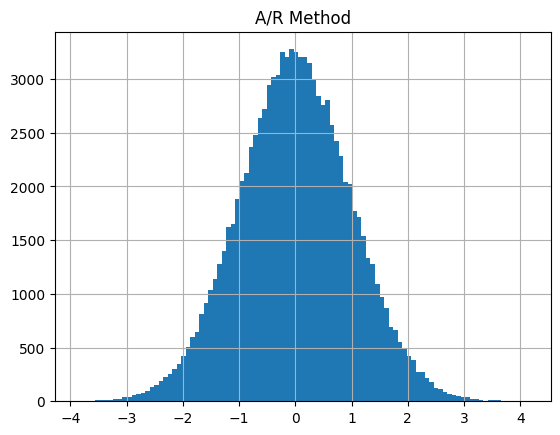

In [2]:
def f(x):
    return np.exp(-(x ** 2) / 2) / np.sqrt(2 * np.pi)
def g(x):
    return (x <= 0) * 0.5 * np.exp(x) + (x > 0) * 0.5 * np.exp(-x)

def generate_point():
    side = np.random.uniform(-1, 1)
    u = np.random.uniform(0, 0.5)
    if side > 0:
        x = -np.log(2*u)
    else:
        x = np.log(2*u)
    y = np.random.uniform(0, 1)
    return x, y

a = np.sqrt(2 * np.exp(1) / np.pi)
X = np.zeros(n)
total_uniforms = 0
tic = time.perf_counter()
for i in range(n):
    x_n, y_n = generate_point()
    total_uniforms += 3
    while a * g(x_n) * y_n >= f(x_n):
        x_n, y_n = generate_point()
        total_uniforms += 3
    X[i] = x_n
toc = time.perf_counter()
print(f"Avg uniforms per sample = {total_uniforms/n:.4f}  (exact: 3a = {3*a:.4f})")
print(f"Avg time per sample     = {(toc-tic)/n*1e6:.4f} microseconds")
import pandas as pd
pd.Series(X).rename('A/R Method').to_frame().hist(bins=100)

### 1.2 Box-Muller

**Solution**


Each iteration draws 2 uniforms and produces 2 normals, so average uniforms per sample $= 1$.

Let $V = -2\ln(U_1)$ where $U_1 \sim \text{Uniform}(0,1)$. Then $V$ has pdf $f_V(v) = \frac{1}{2}e^{-v/2}$ (chi-squared, 2 df).

CDF: $F_V(v) = 1 - e^{-v/2}$. Setting $u = 1 - e^{-v/2}$:

$$v = -2\ln(1-u) \sim -2\ln(u) \quad \text{(since } 1-U \sim U\text{)}$$

Let $W \sim \text{Uniform}(0, 2\pi)$. Then:

$$X = \sqrt{V}\cos(W), \quad Y = \sqrt{V}\sin(W) \stackrel{\text{iid}}{\sim} N(0,1)$$

Avg uniforms per sample = 1 (2 uniforms per 2 samples)
Avg time per sample     = 1.4083 microseconds


array([[<Axes: title={'center': 'Box-Muller Method'}>]], dtype=object)

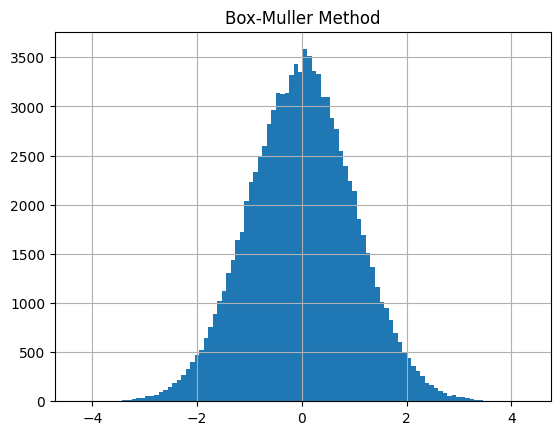

In [3]:
tic = time.perf_counter()
X_bm = np.zeros(n)
midpt = int(n/2)
for i in range(midpt):
    u1 = np.random.uniform(0, 1)
    v = -2*np.log(u1)
    w = np.random.uniform(0, 2*np.pi)
    x_n = np.sqrt(v) * np.cos(w)
    y_n = np.sqrt(v) * np.sin(w)
    X_bm[i] = x_n
    X_bm[i+midpt] = y_n
toc = time.perf_counter()
print(f"Avg uniforms per sample = 1 (2 uniforms per 2 samples)")
print(f"Avg time per sample     = {(toc-tic)/n*1e6:.4f} microseconds")
pd.Series(X_bm).rename('Box-Muller Method').to_frame().hist(bins=100)

### 1.3 Marsaglia-Bray

**Solution**


Generate $U_1, U_2 \sim \text{Uniform}(-1,1)$; accept if $U_1^2 + U_2^2 \leq 1$. Each accepted pair gives two $N(0,1)$ samples.

$P(\text{accept}) = \pi/4$, so expected trials per accepted pair $= 4/\pi$. Each trial draws 2 uniforms, each acceptance yields 2 normals:

$$\text{avg uniforms per sample} = \frac{2 \cdot (4/\pi)}{2} = \frac{4}{\pi} \approx 1.27$$

Avg uniforms per sample = 1.2751  (exact: 4/pi = 1.2732)
Avg time per sample     = 1.5927 microseconds


array([[<Axes: title={'center': 'Marsaglia-Bray Method'}>]], dtype=object)

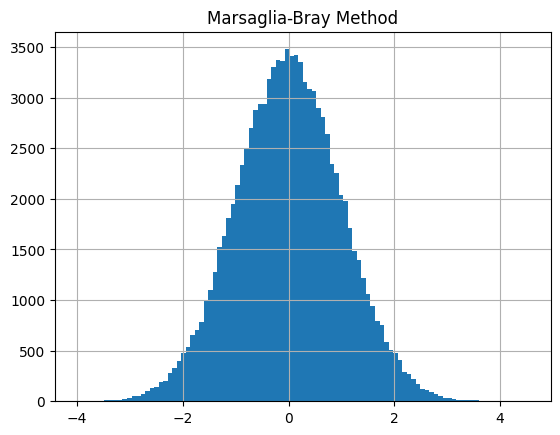

In [4]:
tic = time.perf_counter()
X_mb = np.zeros(n)
midpt = int(n/2)
total_uniforms_mb = 0
for i in range(midpt):
    u1 = np.random.uniform(-1, 1)
    u2 = np.random.uniform(-1, 1)
    total_uniforms_mb += 2
    while u1**2 + u2**2 > 1:
        u1 = np.random.uniform(-1, 1)
        u2 = np.random.uniform(-1, 1)
        total_uniforms_mb += 2
    s = u1**2 + u2**2
    X_mb[i] = u1 * np.sqrt(-2*np.log(s)/s)
    X_mb[midpt+i] = u2 * np.sqrt(-2*np.log(s)/s)
toc = time.perf_counter()
print(f"Avg uniforms per sample = {total_uniforms_mb/n:.4f}  (exact: 4/pi = {4/np.pi:.4f})")
print(f"Avg time per sample     = {(toc-tic)/n*1e6:.4f} microseconds")
pd.Series(X_mb).rename('Marsaglia-Bray Method').to_frame().hist(bins=100)

# Problem 2

Use the acceptance-rejection method to generate a random variable $X$ with the pdf

$$f_{X}(x) = \left\{ \begin{array}{cc} \frac{3}{16}\left(3 + x - x^2\right) & 0 \leq x \leq 2 \\ 0 & \textrm{otherwise} \end{array} \right.$$

You can use a bounding rectangle (which amounts to using a uniform density $g(x)$), but you should choose the rectangle to be as small as possible (i.e., choose the optimal value of $a$).

Use your simulation code to generate at least $10,000$ samples.  Estimate the expected value of $X$ and compute the expected number of trials needed per accepted sample.

**Solution**

**Bounding rectangle:** $x \in [0,2]$, find max of $f$:

$$f'(x) = \frac{3}{16}(1 - 2x) = 0 \implies x = \tfrac{1}{2}$$

$$f\!\left(\tfrac{1}{2}\right) = \frac{3}{16}\left(3 + \tfrac{1}{2} - \tfrac{1}{4}\right) = \frac{3}{16} \cdot 3.25 = 0.609375$$

With $g(x) = \text{Uniform}(0,2)$, so $g(x) = \frac{1}{2}$:

$$a = \frac{\max f(x)}{g(x)} = \frac{0.609375}{0.5} = 1.21875$$

Expected trials per sample $= a = 1.21875$.

E[X]                      = 0.87661
Avg trials per sample     = 1.2193  (exact: a = 1.2188)


array([[<Axes: title={'center': 'Problem 2'}>]], dtype=object)

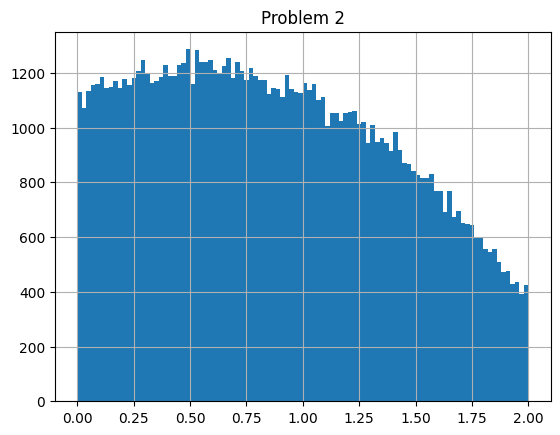

In [5]:
def f2(x):
    return (3/16) * (3 + x - x**2)

f_max = (3/16) * (3 + 0.5 - 0.25)  # = 0.609375
a_2 = f_max / 0.5

X_2 = np.zeros(n)
total_trials = 0
for i in range(n):
    x = np.random.uniform(0, 2)
    y = np.random.uniform(0, f_max)
    total_trials += 1
    while y > f2(x):
        x = np.random.uniform(0, 2)
        y = np.random.uniform(0, f_max)
        total_trials += 1
    X_2[i] = x

print(f"E[X]                      = {np.mean(X_2):.5f}")
print(f"Avg trials per sample     = {total_trials/n:.4f}  (exact: a = {a_2:.4f})")
pd.Series(X_2).rename('Problem 2').to_frame().hist(bins=100)

# Problem 3

Suppose that an insurance company pays out $N\sim \textrm{Poisson}(10)$ claims per week and the payout for each claim is $X_i \sim \textrm{Exp}(0.1)$.  (All of the random variables $N$ and $X_i$ are mutually independent.)  The total amount that the insurance company needs to pay out each week is given by

$$X = \sum_{i = 1}^{N}X_i$$

Use Monte Carlo simulation to estimate the expected value of $X$ with at least $10,000$ samples.  You should decide on an appropriate method.  If you use the inverse transform method, show how to find and invert the cdf analytically (i.e., don't just solve numerically).  If you use the composition method, explain how to generate all the necessary intermediate variables.  If you use the acceptance-rejection method, explain how to choose an appropriate bounding density $g(x)$ and find the optimal value of $a$.

**Solution**

Using the **composition method**: draw $N \sim \text{Poisson}(10)$, then sum $N$ independent draws from $\text{Exp}(0.1)$.

**Exponential inverse transform:** CDF is $F(x) = 1 - e^{-0.1x}$. Setting $u = 1 - e^{-0.1x}$:

$$F^{-1}(u) = -\frac{\ln(1-u)}{0.1}$$

**Expected value:** $\mathbb{E}[X] = \mathbb{E}[N] \cdot \mathbb{E}[X_i] = 10 \cdot 10 = 100$.

In [6]:
lam = 10
def poisson_inv_cdf(u, lam, k_max=50):
    k = 0
    cdf = np.exp(-lam)
    while cdf < u and k < k_max:
        k += 1
        cdf += np.exp(-lam) * lam**k / factorial(k)
    return k

K = np.zeros(n)
for i in range(n):
    u = np.random.uniform(0, 1)
    k = poisson_inv_cdf(u, lam)
    k_n = [-np.log(1 - np.random.uniform(0, 1)) / 0.1 for k_i in range(k)]
    K[i] = np.sum(k_n)

print(f"E[X] = {np.mean(K):.4f}  (exact: 100)")

E[X] = 100.0599  (exact: 100)


# Problem 4

If $\{W_t\}$ is a standard Brownian motion, then the maximum of $W_t$ over the time interval $[0, 1]$ is a random variable $M$ with pdf

$$f_{M}(x) = \left\{ \begin{array}{cc} \sqrt{\frac{2}{\pi}}e^{-x^2/2} & x \geq 0, \\ 0 & \textrm{otherwise}. \end{array} \right.$$

(We will discuss more details of Brownian motion soon, but they are not needed for this problem.)

Use Monte Carlo simulation to estimate the expected value of $M$ with at least $10,000$ samples.  You should decide on an appropriate method.  If you use the inverse transform method, show how to find and invert the cdf analytically (i.e., don't just solve numerically).  If you use the composition method, show how to write $f_M$ as a mixture and explain how to generate all the necessary intermediate variables.  If you use the acceptance-rejection method, explain how to choose an appropriate bounding density $g(x)$ and find the optimal value of $a$.

**Solution**

Note that $f_M$ is the pdf of $|Z|$ where $Z \sim N(0,1)$.

**Proof:** For $x \geq 0$:

$$P[|Z| \leq x] = P[-x \leq Z \leq x] = F_Z(x) - F_Z(-x)$$

Differentiating (chain rule gives $+$ on the second term):

$$f_{|Z|}(x) = f_Z(x) + f_Z(-x) = \frac{2}{\sqrt{2\pi}}e^{-x^2/2} = \sqrt{\frac{2}{\pi}}e^{-x^2/2} = f_M(x) \checkmark$$

So we generate $Z \sim N(0,1)$ via Box-Muller and return $|Z|$.

E[M]                = 0.79967
Avg time per sample = 1.7131 microseconds


array([[<Axes: title={'center': 'Problem 4'}>]], dtype=object)

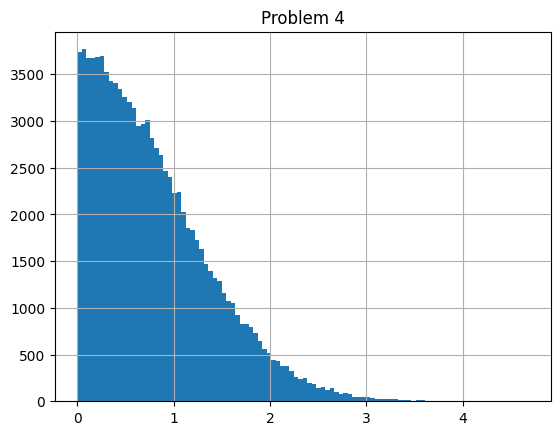

In [7]:
tic = time.perf_counter()
X_4 = np.zeros(n)
midpt = int(n/2)
for i in range(midpt):
    u1 = np.random.uniform(0, 1)
    v = -2*np.log(u1)
    w = np.random.uniform(0, 2*np.pi)
    x_n = np.sqrt(v) * np.cos(w)
    y_n = np.sqrt(v) * np.sin(w)
    X_4[i] = np.abs(x_n)
    X_4[i+midpt] = np.abs(y_n)
toc = time.perf_counter()
print(f"E[M]                = {np.mean(X_4):.5f}")
print(f"Avg time per sample = {(toc-tic)/n*1e6:.4f} microseconds")
pd.Series(X_4).rename('Problem 4').to_frame().hist(bins=100)

# Problem 5

If $\{W_t\}$ is a standard Brownian motion and we know that $W_0 = W_1 = 0$ (in other words, $W_t$ is a *Brownian bridge*), then the maximum of $W_t$ over the time interval $[0, 1]$ is a random variable $M$ with pdf

$$f_{M}(x) = \left\{ \begin{array}{cc} 4xe^{-2x^2} & x \geq 0, \\ 0 & \textrm{otherwise}. \end{array} \right.$$

(We will discuss more details of Brownian motion soon, but they are not needed for this problem.)

Use Monte Carlo simulation to estimate the expected value of $M$ with at least $10,000$ samples.  You should decide on an appropriate method.  If you use the inverse transform method, show how to find and invert the cdf analytically (i.e., don't just solve numerically).  If you use the composition method, show how to write $f_M$ as a mixture and explain how to generate all the necessary intermediate variables.  If you use the acceptance-rejection method, explain how to choose an appropriate bounding density $g(x)$ and find the optimal value of $a$.

**Solution**

Using the **inverse transform method**. Let $u = -2x^2$, $du = -4x\,dx$:

$$F_M(x) = \int_0^x 4t\,e^{-2t^2}\,dt = \int_0^{-2x^2} -e^u\,du = \Big[-e^u\Big]_0^{-2x^2} = 1 - e^{-2x^2}$$

Sanity check: $F_M(0) = 0$, $F_M(\infty) = 1$. $\checkmark$

Inverting: set $u = 1 - e^{-2x^2}$:

$$e^{-2x^2} = 1-u \implies x^2 = -\frac{\ln(1-u)}{2} \implies F^{-1}(u) = \sqrt{-\frac{\ln(1-u)}{2}}$$

E[M] = 0.62594


array([[<Axes: title={'center': 'Problem 5'}>]], dtype=object)

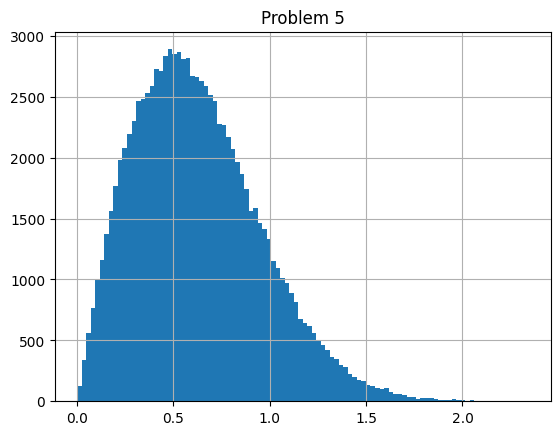

In [8]:
X_5 = np.zeros(n)
for i in range(n):
    u = np.random.uniform(0, 1)
    x = np.sqrt((-1/2) * np.log(1-u))
    X_5[i] = x

print(f"E[M] = {np.mean(X_5):.5f}")
pd.Series(X_5).rename('Problem 5').to_frame().hist(bins=100)